In [102]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [103]:
df = pd.read_csv('healthy_eating_dataset.csv',usecols=[0,5,6,7,8,9,10,11,12,13,15,16,18,])

In [104]:
df.head()

,meal_id,calories,protein_g,carbs_g,fat_g,fiber_g,sugar_g,sodium_mg,cholesterol_mg,serving_size_g,prep_time_min,cook_time_min,is_healthy
0,1,737,52.4,43.9,34.3,16.8,42.9,2079,91,206,47,56,0
1,2,182,74.7,144.4,0.1,22.3,38.6,423,7,317,51,34,0
2,3,881,52.9,97.3,18.8,20.0,37.5,2383,209,395,58,29,0
3,4,427,17.5,73.1,7.6,9.8,41.7,846,107,499,14,81,0
4,5,210,51.6,104.3,26.3,24.8,18.2,1460,42,486,47,105,0


In [105]:
df.shape

(2000, 13)

In [106]:
x = df.iloc[:,0:13]
y = df.iloc[:,-1]

In [107]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.8,random_state=42)

In [108]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression()

In [109]:
lr.fit(x_train, y_train)

E:\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [110]:
y_pred = lr.predict(x_test)

In [111]:
from sklearn.metrics import accuracy_score
accuracy_score(y_pred,y_test)

0.94375

In [117]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
x_train_trf = pca.fit_transform(x_train)
x_test_trf = pca.transform(x_test)

In [118]:
pca.explained_variance_ratio_

array([0.54086698, 0.33583385])

In [119]:
np.cumsum(pca.explained_variance_ratio_)

array([0.54086698, 0.87670082])

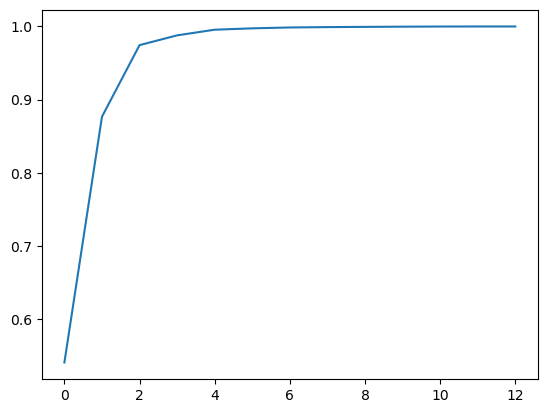

In [115]:
plt.plot(np.cumsum(pca.explained_variance_ratio_))

In [120]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression()

lr.fit(x_train_trf, y_train)

y_pred = lr.predict(x_test_trf)

from sklearn.metrics import accuracy_score
accuracy_score(y_pred,y_test)

0.91